# Task 2: Season Classification

COSC2753 | Machine Learning

## 1. Introduction

This follow-up experiment compares a majority reference, HOG + HSV logistic
regression, and one plain three-block CNN per target. The goal is a model that is
effective and easy to explain. All models are trained from scratch on the
supplied training rows. The frozen group split and training-only normalization
are preserved. Literal `NA` remains a usage label.

The same CNN settings are used for every target: ordinary cross-entropy, Adam
at 0.001, batch size 64, at most 30 epochs, patience 5 and horizontal flips only.
Select on validation macro F1; within 0.01, prefer lower validation ECE, then
parameter count. The majority reference cannot win.

Earlier test results have already been seen. This is explicitly a follow-up
after test exposure, not a fresh untouched holdout. No follow-up test scores are
used to tune or select models. See [the simplification record](../docs/SIMPLIFICATION_EXPERIMENT.md).

## 2. Library Imports and Setup

In [1]:
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch

from app.server.utils.modeling import SimpleCNN
from scripts.classification import make_loader, train_cnn, predict_cnn, comparison_row
from app.server.utils.classifier import FashionClassifier
from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG, handcrafted_feature
from evaluation import calibration_table, expected_calibration_error, high_confidence_errors, ordered_estimator_probabilities, saved_model_robustness, select_validation_candidate, subgroup_metrics
from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame
torch.set_num_threads(4)
seed_everything(SEED)
torch.manual_seed(SEED)
DEVICE = select_torch_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
DEVICE


Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

## 3. Frozen Data and Season EDA

In [2]:
TARGET = 'season'
train_df = task_frame(TARGET, 'train')
validation_df = task_frame(TARGET, 'validation')
test_df = task_frame(TARGET, 'test')
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
labels = sorted(train_df[TARGET].unique())
label_to_index = {label: index for index, label in enumerate(labels)}
def supported_macro_f1(truth, predictions):
    return f1_score(truth, predictions, labels=np.unique(truth), average='macro', zero_division=0)
pd.DataFrame({
    'train': train_df[TARGET].value_counts(),
    'validation': validation_df[TARGET].value_counts(),
    'test': test_df[TARGET].value_counts(),
}).fillna(0).astype(int)

,train,validation,test
season,,,
Summer,13352,2918,2865
Fall,7363,1598,1551
Winter,5244,1083,1051
Spring,1079,239,248


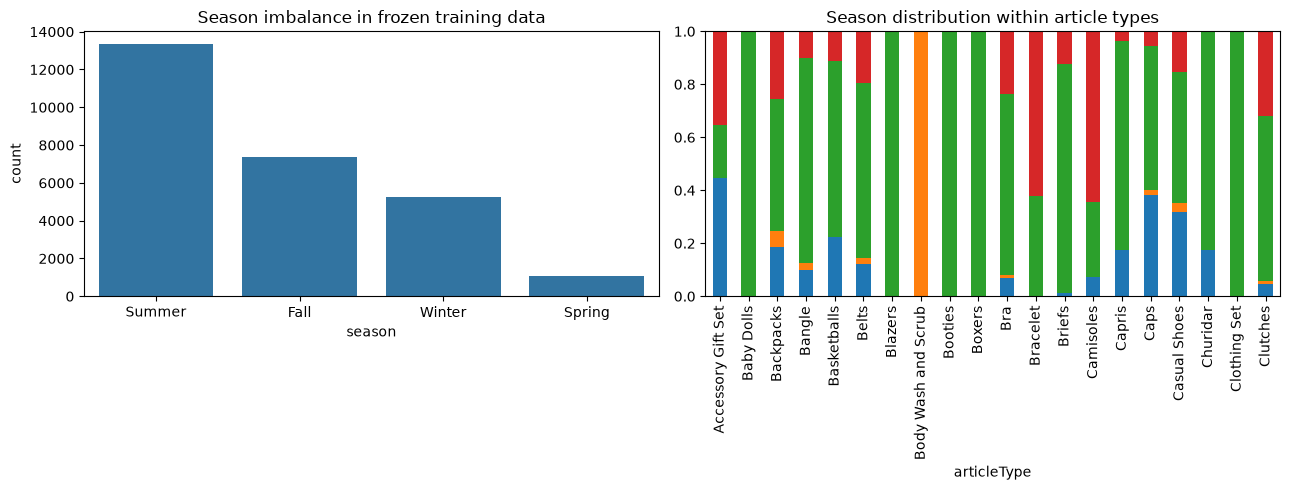

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=train_df, x=TARGET, order=train_df[TARGET].value_counts().index, ax=axes[0])
axes[0].set_title('Season imbalance in frozen training data')
pd.crosstab(train_df['articleType'], train_df[TARGET], normalize='index').head(20).plot(kind='bar', stacked=True, ax=axes[1], legend=False)
axes[1].set_title('Season distribution within article types')
plt.tight_layout()

### 3.1 Observations

Season has 27,038 training, 5,838 validation and 5,715 test rows after target-specific blank exclusion. Summer has 13,352 training examples and Spring 1,079, a roughly 12.4:1 ratio. All four evaluated labels occur in training. These are the shared frozen product-name/duplicate-group partitions, not a new season-stratified split.

The article-type crosstab shows associations between category and catalogue season. These motivate a shortcut-learning hypothesis; they do not establish what a trained image model uses. The new experiment compares a plain CNN with a fixed handcrafted baseline. It does not isolate the effects of architecture versus augmentation or optimizer.

## 4. Majority Baseline

In [4]:
dummy = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(train_df), 1)), train_df[TARGET])
dummy_predictions = dummy.predict(np.zeros((len(validation_df), 1)))
dummy_probabilities = ordered_estimator_probabilities(dummy, np.zeros((len(validation_df), 1)), labels)
majority_metrics = {'accuracy': accuracy_score(validation_df[TARGET], dummy_predictions), 'macro_f1': supported_macro_f1(validation_df[TARGET], dummy_predictions)}
majority_metrics

{'accuracy': 0.499828708461802, 'macro_f1': 0.16662859753312015}

## 5. HOG + HSV Classical Baseline

In [5]:
def handcrafted_feature_path(path):
    with Image.open(path) as source:
        return handcrafted_feature(source, DEFAULT_FEATURE_CONFIG)

train_features = np.vstack([handcrafted_feature_path(path) for path in train_df.image_path])
validation_features = np.vstack([handcrafted_feature_path(path) for path in validation_df.image_path])
linear_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'),
).fit(train_features, train_df[TARGET])
linear_predictions = linear_baseline.predict(validation_features)
linear_probabilities = ordered_estimator_probabilities(linear_baseline, validation_features, labels)
linear_metrics = {'accuracy': accuracy_score(validation_df[TARGET], linear_predictions), 'macro_f1': supported_macro_f1(validation_df[TARGET], linear_predictions)}
linear_metrics

{'accuracy': 0.6289825282631039, 'macro_f1': 0.5877104790219029}

## 6. Image pipeline

Resize and normalize every image. Only training images receive random horizontal flips. The dataset and loaders are defined in [classification.py](../scripts/classification.py).

In [6]:
train_loader = make_loader(train_df, TARGET, labels, normalisation, training=True)
validation_loader = make_loader(validation_df, TARGET, labels, normalisation)
test_loader = make_loader(test_df, TARGET, labels, normalisation)


## 7. Plain CNN architecture

| Stage | Operation | Purpose |
|---|---|---|
| Input | RGB, 128 high x 96 wide; frozen training normalization | Consistent input |
| Block 1 | Conv 3x3, 32 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Local edges |
| Block 2 | Conv 3x3, 64 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Combine patterns |
| Block 3 | Conv 3x3, 128 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Higher-level features |
| Head | Adaptive average pool 2x2 -> Flatten -> Dense 128 -> ReLU -> Dropout 0.2 -> output | Predict target logits |

There are no residual connections or pretrained weights. The single definition
in [modeling.py](../app/server/utils/modeling.py) is shared with API inference.
The table describes the intended roles; it is not evidence of what each filter learned.

In [7]:
example_model = SimpleCNN(len(labels))
print(example_model)
print('Parameters:', sum(p.numel() for p in example_model.parameters()))


SimpleCNN(
  (layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(2, 2))
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=512, out_features=128, bias=True)
    (15): ReLU()

## 8. Train one CNN

The short shared [training loop](../scripts/classification.py) performs the same
steps each epoch: predict, compute ordinary cross-entropy, backpropagate and update
with Adam; then evaluate without gradients. Save the state whenever validation
macro F1 improves and stop after five non-improving epochs (30 maximum).
There is no loss-mode search, scheduler or per-target hyperparameter tuning.
Training F1 uses augmented images and training-mode layers, so its gap from
validation F1 is descriptive rather than an identical-conditions comparison.

Epoch 01: train F1=0.3661, validation F1=0.4218, 28.0s


Epoch 02: train F1=0.4711, validation F1=0.4467, 28.0s


Epoch 03: train F1=0.5883, validation F1=0.5897, 27.2s


Epoch 04: train F1=0.6222, validation F1=0.5862, 27.2s


Epoch 05: train F1=0.6416, validation F1=0.6012, 26.7s


...

Epoch 24: train F1=0.7308, validation F1=0.6475, 24.8s


Epoch 25: train F1=0.7298, validation F1=0.6391, 24.9s


Epoch 26: train F1=0.7362, validation F1=0.6912, 24.9s


Epoch 27: train F1=0.7367, validation F1=0.6625, 24.9s


Epoch 28: train F1=0.7381, validation F1=0.6945, 24.8s


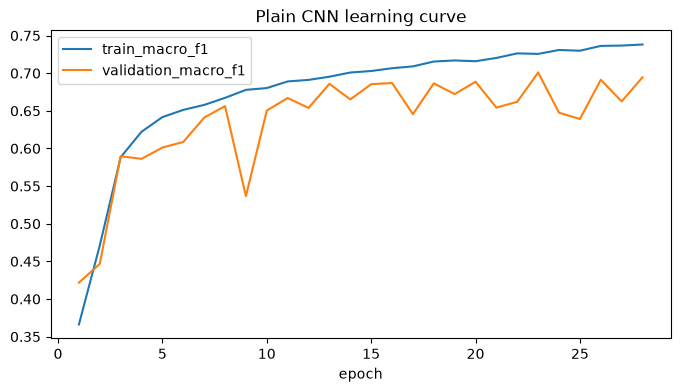

In [8]:
seed_everything(SEED)
torch.manual_seed(SEED)
cnn_model = SimpleCNN(len(labels))
cnn_model, cnn_history = train_cnn(
    cnn_model, train_loader, validation_loader, DEVICE,
    max_epochs=30, patience=5,
)
cnn_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'],
                 title='Plain CNN learning curve', figsize=(8, 4))
plt.show()


In [9]:
validation_truth = np.asarray([label_to_index[label] for label in validation_df[TARGET]])
cnn_probabilities = predict_cnn(cnn_model, validation_loader, DEVICE)
linear_parameters = linear_baseline[-1].coef_.size + linear_baseline[-1].intercept_.size
cnn_parameters = sum(parameter.numel() for parameter in cnn_model.parameters())
comparison = pd.DataFrame([
    comparison_row('majority', 'reference_only', validation_truth,
                   dummy_probabilities, 1, eligible=False),
    comparison_row('hog_hsv_logistic_regression', 'hog_hsv_logistic_regression',
                   validation_truth, linear_probabilities, linear_parameters),
    comparison_row('cnn_ordinary', 'simple_cnn', validation_truth,
                   cnn_probabilities, cnn_parameters, epochs=len(cnn_history)),
]).set_index('method')
display(comparison)
SELECTED_METHOD = select_validation_candidate(comparison.loc[comparison.eligible_for_selection])
SELECTED_MODEL_TYPE = comparison.loc[SELECTED_METHOD, 'model_type']
best_f1 = float(comparison.loc[SELECTED_METHOD, 'validation_macro_f1'])
if SELECTED_MODEL_TYPE == 'simple_cnn':
    SELECTED_LOSS_MODE = 'ordinary'
    model = cnn_model
    history = cnn_history
else:
    SELECTED_LOSS_MODE = None
    model = linear_baseline
    history = pd.DataFrame([{'method': SELECTED_METHOD, **comparison.loc[SELECTED_METHOD].to_dict()}])
print(f'Selected {SELECTED_METHOD!r} before follow-up test evaluation.')

cnn_history.to_csv(ROOT / 'models' / 'season_cnn_history.csv', index=False)


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.499829,0.166629,0.500171,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.628983,0.587710,0.088660,5140,0,True
cnn_ordinary,simple_cnn,0.717883,0.700885,0.019207,159876,28,True


Selected 'cnn_ordinary' before follow-up test evaluation.


### 8.1 Training and selection analysis

Validation macro F1: majority 0.1666, HOG+HSV 0.5877, plain CNN 0.7009. The predeclared selection rule chooses **cnn_ordinary** (selection-table validation ECE 0.0192).

The CNN's best epoch is 23; it runs for 28 epochs. At that epoch training/validation macro F1 are 0.7256/0.7009, a gap of 0.0247. Training uses flips, dropout and batch statistics, so these are different evaluation conditions. The full CNN history is retained even when the classical model wins.

## 9. Final Evaluation

In [10]:
test_truth = np.asarray([label_to_index[label] for label in test_df[TARGET]])
if SELECTED_MODEL_TYPE == 'simple_cnn':
    test_probabilities = predict_cnn(model, test_loader, DEVICE)
else:
    test_features = np.vstack([handcrafted_feature_path(path) for path in test_df.image_path])
    test_probabilities = ordered_estimator_probabilities(model, test_features, labels)
test_predictions = test_probabilities.argmax(1)
test_metrics = {'accuracy': accuracy_score(test_truth, test_predictions), 'ece': expected_calibration_error(test_truth, test_probabilities), 'macro_f1': supported_macro_f1(test_truth, test_predictions)}
test_metrics


{'accuracy': 0.6951881014873141,
 'ece': 0.021759590039833125,
 'macro_f1': 0.6826529481547245}

              precision    recall  f1-score   support

        Fall       0.59      0.70      0.64      1551
      Spring       0.96      0.52      0.67       248
      Summer       0.72      0.75      0.73      2865
      Winter       0.82      0.59      0.69      1051

    accuracy                           0.70      5715
   macro avg       0.77      0.64      0.68      5715
weighted avg       0.71      0.70      0.70      5715



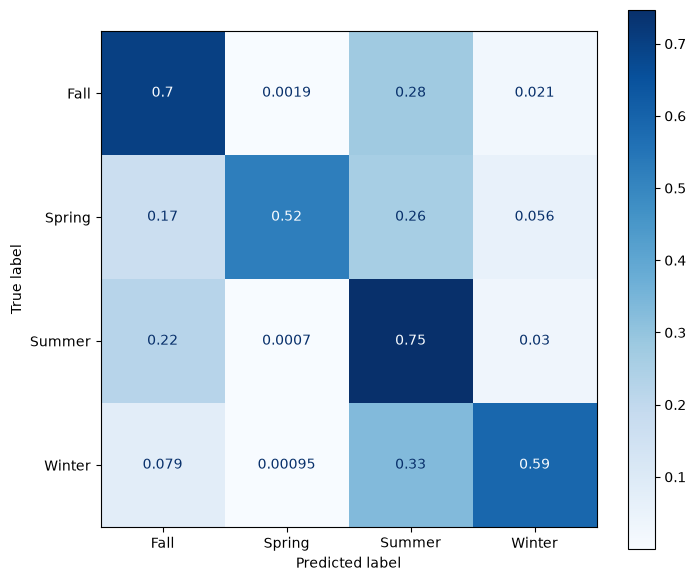

In [11]:
print(classification_report(
    test_truth, test_predictions, labels=np.arange(len(labels)), target_names=labels, zero_division=0,
))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    test_truth, test_predictions, labels=np.arange(len(labels)), display_labels=labels,
    normalize='true', ax=ax, cmap='Blues',
)
plt.show()

### 9.1 Calibration and failure analysis

In [12]:
display(calibration_table(test_truth, test_probabilities))
display(high_confidence_errors(test_df, TARGET, labels, test_truth, test_predictions, test_probabilities))
truth_labels = [labels[index] for index in test_truth]
prediction_labels = [labels[index] for index in test_predictions]
display(subgroup_metrics(test_df, truth_labels, prediction_labels, group_column='articleType', minimum_support=30))

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",NaN,NaN,0
"(0.3, 0.4]",0.372949,0.357895,190
"(0.4, 0.5]",0.455119,0.421808,697
"(0.5, 0.6]",0.548789,0.526891,1190
"(0.6, 0.7]",0.644502,0.646067,890
"(0.7, 0.8]",0.750268,0.803328,661
"(0.8, 0.9]",0.849774,0.839109,808


,id,articleType,season,image_path,truth,prediction,confidence
5681,51579,Watches,Summer,D:\khoile\programs\fashion-intelligence-classi...,Summer,Winter,0.999154
3686,31858,Watches,Summer,D:\khoile\programs\fashion-intelligence-classi...,Summer,Winter,0.998288
4303,37234,Wallets,Summer,D:\khoile\programs\fashion-intelligence-classi...,Summer,Spring,0.997828
47,2030,Tshirts,Fall,D:\khoile\programs\fashion-intelligence-classi...,Fall,Summer,0.997156
5109,45130,Watches,Summer,D:\khoile\programs\fashion-intelligence-classi...,Summer,Winter,0.996479
3455,29988,Watches,Summer,D:\khoile\programs\fashion-intelligence-classi...,Summer,Winter,0.996445
5126,45271,Watches,Summer,D:\khoile\programs\fashion-intelligence-classi...,Summer,Winter,0.986576
3714,32027,Socks,Summer,D:\khoile\programs\fashion-intelligence-classi...,Summer,Winter,0.984942
1344,12253,Shirts,Winter,D:\khoile\programs\fashion-intelligence-classi...,Winter,Fall,0.982882
161,3131,Tshirts,Fall,D:\khoile\programs\fashion-intelligence-classi...,Fall,Summer,0.980791


,articleType,support,accuracy,macro_f1
32,Wallets,125,0.384000,0.206676
9,Flip Flops,118,0.432203,0.224614
1,Belts,132,0.727273,0.231111
10,Formal Shoes,114,0.377193,0.231490
4,Caps,42,0.452381,0.236111
19,Sandals,118,0.491525,0.262192
21,Shorts,90,0.622222,0.272606
23,Sports Shoes,328,0.542683,0.279776
5,Casual Shoes,438,0.518265,0.297400
0,Backpacks,110,0.472727,0.307852


### 9.2 Failure analysis

Full CPU test accuracy is 0.6952, supported-label macro F1 0.6827, and ECE 0.0218. The notebook test cells run on CUDA; the separate CPU verification allows and records small numerical differences, with a maximum permitted absolute metric delta of 0.001.

The weakest supported labels include Fall (F1 0.639, n=1551), Spring (F1 0.674, n=248), Winter (F1 0.686, n=1051). Spring has the smallest test support, so its estimate is less precise than those of the larger seasons. The class and subgroup tables describe errors; they do not establish which visual cues caused them.

On the same fixed 300-image robustness sample, macro F1 is: clean 0.7109, brightness_0.8 0.2864, brightness_1.2 0.5746, gaussian_blur_0.7 0.6705. These are sample scores, not full-test scores. The selected checkpoint occupies 0.62 MiB. CPU timing is machine-dependent and includes image preprocessing; it is not an end-to-end web benchmark.


The most important robustness result is the darkening failure: multiplying
brightness by 0.8 reduces sample macro F1 from 0.7109 to 0.2864, an absolute
drop of about 0.4245. This is a substantial weakness, not a minor change hidden
by the small difference in clean test scores. Removing colour augmentation and
changing the architecture happened together; the results do not establish which
change caused the sensitivity. The current model should therefore be described
as effective on clean catalogue images but unreliable under this tested lighting
change. No new settings were chosen from this test result.

Subgroups also vary: Wallets have macro F1 0.2067 (125 images), Flip Flops 0.2246
(118), and Belts 0.2311 (132). Confident mistakes include Summer watches predicted
as Winter (IDs 51579 and 31858). These observations support investigating catalogue
associations; they do not prove shortcut learning. On clean test images, the
highest-confidence bin has 0.9595 mean confidence and 0.9382 accuracy (1,278
examples). Good aggregate clean calibration does not guarantee robustness to
lighting changes or reliability for every article type.

## 10. Save the Selected Model

In [13]:
checkpoint_path = ROOT / 'models' / 'season_model.pt'
validation_metrics = {key: float(comparison.loc[SELECTED_METHOD, key]) for key in ('validation_accuracy', 'validation_macro_f1', 'validation_ece')}
if SELECTED_MODEL_TYPE == 'simple_cnn':
    checkpoint = {
        'model_type': 'simple_cnn', 'target': TARGET, 'labels': labels,
        'state_dict': model.cpu().state_dict(), 'mean': normalisation['mean'], 'std': normalisation['std'],
        'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'loss_mode': SELECTED_LOSS_MODE,
    }
else:
    checkpoint = {
        'model_type': 'hog_hsv_logistic_regression', 'target': TARGET, 'labels': labels,
        'estimator': model, 'feature_config': DEFAULT_FEATURE_CONFIG,
    }
checkpoint.update({'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': best_f1, 'validation_metrics': validation_metrics, 'test_metrics': test_metrics, 'seed': SEED})
checkpoint['experiment'] = 'simple_cnn_v1'
torch.save(checkpoint, checkpoint_path)
cpu_predictor = FashionClassifier(checkpoint_path, device='cpu')
robustness = saved_model_robustness(cpu_predictor, test_df, TARGET, SEED)
display(robustness)
print(f'Checkpoint size: {checkpoint_path.stat().st_size / 1024**2:.2f} MiB')
history.to_csv(ROOT / 'models' / 'season_history.csv', index=False)
comparison.to_csv(ROOT / 'models' / 'season_comparison.csv')
checkpoint_path

,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.736667,0.710899,0.717445,1.866717
brightness_0.8,300,0.553333,0.286418,0.655544,1.811897
brightness_1.2,300,0.633333,0.574553,0.692106,1.810576
gaussian_blur_0.7,300,0.706667,0.670537,0.634643,1.901013


Checkpoint size: 0.62 MiB


WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/season_model.pt')

## 11. Final Prediction

The save cell loads the checkpoint explicitly on CPU and exercises it on the fixed robustness sample. The final CPU smoke cell also predicts a validation image using only the saved artifact. The standalone helper accepts `python scripts/task2_season_classification.py path/to/image.jpg`; force CPU with `CUDA_VISIBLE_DEVICES=-1` when checking its default device selection.

## 12. Ultimate judgement

The selected cnn_ordinary reaches validation macro F1 0.7009, compared with 0.7103 for the previous selected model (change -0.0095). The simplified experiment uses one ordinary-loss plain CNN and a classical baseline per target. It removes the residual architecture and loss-mode search from current training. The same settings were used for every target; this combined change does not isolate a causal improvement. Use it for catalogue tagging with the reported rare-class and confidence limitations. The previously inspected internal test is a follow-up evaluation, not evidence from an untouched holdout.


The smaller model is a simplicity/clean-performance tradeoff, not an overall
robustness improvement. Its large darkening failure is a material limitation of
the delivered model and belongs in the final report alongside the smaller size.

In [14]:
with Image.open(validation_df.image_path.iloc[0]) as image:
    print(FashionClassifier(ROOT / 'models' / 'season_model.pt', device='cpu').predict(image))

{'target': 'season', 'label': 'Fall', 'confidence': 0.6526468396186829, 'top_k': [{'label': 'Fall', 'confidence': 0.6526468396186829}, {'label': 'Summer', 'confidence': 0.34160301089286804}, {'label': 'Spring', 'confidence': 0.003262032987549901}]}


## 13. Independent literature comparison

Utkarsh Mall, Kevin Matzen, Bharath Hariharan, Noah Snavely and Kavita Bala (2019). [GeoStyle: Discovering Fashion Trends and Events](https://arxiv.org/abs/1908.11412). *ICCV*. [Authors' project and code](https://geostyle.cs.cornell.edu/).

GeoStyle studies temporal clothing trends using 7.7 million street/social-media images from 44 cities. It aggregates calibrated clothing-attribute predictions into weekly trends and models seasonal variation and events. Its attribute pipeline uses GoogLeNet, with ImageNet-pretrained weights available in the authors' implementation. Our task instead predicts one of four catalogue-season labels from a single product image, using a plain CNN trained from scratch. GeoStyle's temporal forecasting evaluation differs from our fixed product-group train/validation/test split, and forecast errors cannot be ranked against our macro F1. It supplies a useful conceptual comparison: real seasonal patterns involve time and geography that our classifier does not observe. It does not validate our catalogue labels as weather suitability or prove that our model uses seasonal visual cues. No external images or pretrained weights were used here.